In [11]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

class TwoStageModel:
    def __init__(self):
        self.clf = RandomForestClassifier(
            n_estimators=100,
            max_depth=10,
            random_state=42
        )
        self.reg = RandomForestRegressor(
            n_estimators=100,
            max_depth=10,
            random_state=42
        )

    def fit(self, X, y):
        # Stage 1: classification target
        y_binary = (y > 0).astype(int)

        # Train classifier on all data
        self.clf.fit(X, y_binary)

        # Train regressor only on non-zero values
        mask = y > 0
        self.reg.fit(X[mask], y[mask])

    def predict(self, X):
        # Stage 1: predict probability of being non-zero
        y_prob = self.clf.predict_proba(X)[:, 1]
        print(y_prob)

        # Stage 2: regression prediction
        y_reg = self.reg.predict(X)
        print(y_reg)

        # Combine
        y_pred = np.where(y_prob > 0.5, y_reg, 0.0)

        return y_pred

In [12]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# --- create fake data ---
np.random.seed(42)

n = 1000
X = np.random.rand(n, 5)

# create sparse target
y = np.zeros(n)

# only some rows have non-zero values
mask = np.random.rand(n) > 0.7
y[mask] = 10 * X[mask, 0] + 5 * X[mask, 1] + np.random.randn(mask.sum())

# --- split ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# --- train model ---
model = TwoStageModel()
model.fit(X_train, y_train)

# --- predict ---
y_pred = model.predict(X_test)
y_pred.shape
# print(y_pred)
# print(y_test)

# # --- evaluate ---
# rmse = np.sqrt(mean_squared_error(y_test, y_pred))
# print("RMSE:", rmse)

[0.2214865  0.21613405 0.28378909 0.26289498 0.19468749 0.39166121
 0.23827483 0.29697453 0.36131757 0.26921652 0.0663952  0.10716934
 0.4714641  0.34429051 0.31004626 0.29054298 0.25981814 0.4671583
 0.43573001 0.25335007 0.27559476 0.28870523 0.14573079 0.30902498
 0.43301307 0.24929939 0.19873016 0.39164953 0.449278   0.18013272
 0.34289105 0.34405653 0.26347417 0.18162477 0.21025508 0.373967
 0.40261952 0.32277692 0.13234403 0.17682219 0.29038835 0.20648394
 0.25439564 0.33975751 0.32438218 0.27861615 0.22735249 0.29644755
 0.36878813 0.39375146 0.27298127 0.14163429 0.41537399 0.16589373
 0.21386731 0.32110148 0.18435229 0.492804   0.20951823 0.21515712
 0.29209821 0.25632366 0.30418548 0.31054122 0.21149286 0.26950253
 0.33247235 0.40898317 0.3311892  0.32144921 0.25972897 0.24306337
 0.19040841 0.23533968 0.13241934 0.34036465 0.44033897 0.2182085
 0.44454897 0.21028526 0.19584246 0.47160114 0.38280469 0.20869905
 0.31004466 0.36232197 0.22218423 0.36127962 0.29062068 0.28253262

(200,)

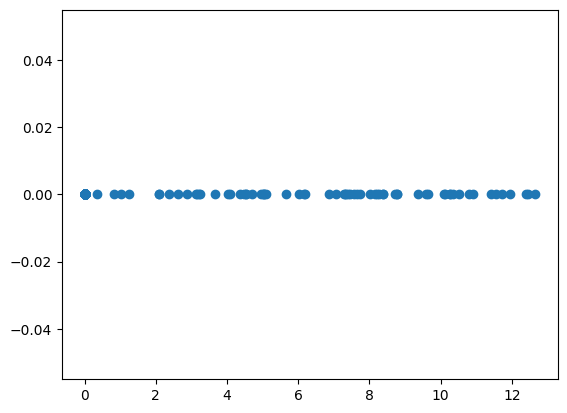

In [8]:
import matplotlib.pyplot as plt
fig = plt.figure()
plt.scatter(y_test, y_pred)
plt.show()
fig.clear()